#Import and Load Data

In [163]:
import pandas as pd

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [164]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [165]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [166]:
#Important Fix
matches=matches.rename(columns={'id': 'match_id'})

#Extract all players

In [167]:
players_bat = deliveries[['match_id', 'batter']].rename(columns={'batter': 'player'})
players_non_striker = deliveries[['match_id', 'non_striker']].rename(columns={'non_striker': 'player'})
players_bowl = deliveries[['match_id', 'bowler']].rename(columns={'bowler': 'player'})

all_players = pd.concat([players_bat, players_non_striker, players_bowl])

# remove duplicates
all_players = all_players.drop_duplicates()

- A player is considered to have played a match if they appear as:
  - batter
  - non_striker
  - bowler
- Extracted player names from all three roles.
- Renamed columns to a common name `player` for consistency.
- Combined all players into a single dataframe.

In [168]:
print(deliveries.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


### Calculate Matches Played

- Grouped data by player.
- Counted unique match IDs for each player.
- This gives the total number of matches played by each player.

In [169]:
matches_played = all_players.groupby('player')['match_id'].nunique().reset_index()
matches_played.columns = ['player', 'matches_played']

### Calculate Player of the Match Awards

- Counted how many times each player won the Player of the Match award using the matches dataset.
- This represents the total number of impactful performances by each player.

In [170]:
potm_counts = matches['player_of_match'].value_counts().reset_index()
potm_counts.columns = ['player', 'potm_awards']

### Combine Matches Played and Awards

- Merged matches played and Player of the Match counts into a single dataframe.
- Filled missing values with 0 for players who never won the award.

In [171]:
player_stats = pd.merge(matches_played, potm_counts, on='player', how='left')
player_stats['potm_awards'] = player_stats['potm_awards'].fillna(0)

### Calculate PotM Ratio

- Calculated the ratio:  
  Player of the Match awards / Matches played
- This measures how frequently a player wins the award per match.

In [172]:
player_stats['potm_ratio'] = player_stats['potm_awards'] / player_stats['matches_played']

### Filter Players

- Considered only players who have played at least 20 matches.
- This avoids misleading results from players with very few matches.

In [173]:
player_stats = player_stats[player_stats['matches_played'] >= 20]

### Identify Playoff Matches

- Filtered matches where match_type is 'Playoffs' or 'Final'.
- These are considered high-pressure matches.

In [174]:
playoff_potm = important_matches['player_of_match'].value_counts().reset_index()
playoff_potm.columns = ['player', 'playoff_potm']

player_stats = pd.merge(player_stats, playoff_potm, on='player', how='left')
player_stats['playoff_potm'] = player_stats['playoff_potm'].fillna(0)

In [175]:
player_stats.head()

,player,matches_played,potm_awards,potm_ratio,playoff_potm
0,A Ashish Reddy,28,0.0,0.000000,0.0
1,A Badoni,35,0.0,0.000000,0.0
2,A Kumble,42,3.0,0.071429,1.0
3,A Mishra,162,12.0,0.074074,0.0
4,A Nehra,88,6.0,0.068182,0.0


### Analyze Playoff Performance

- Counted Player of the Match awards in playoff matches.
- Calculated how many playoff matches each player played.
- Computed playoff PotM ratio for comparison with regular matches.

In [176]:
important_ids = important_matches['match_id']

playoff_players = all_players[all_players['match_id'].isin(important_ids)]

playoff_matches_played = playoff_players.groupby('player')['match_id'].nunique().reset_index()
playoff_matches_played.columns = ['player', 'playoff_matches']

In [177]:
important_matches = matches[matches['match_type'].isin(['Playoffs', 'Final'])]

In [178]:
player_stats = pd.merge(player_stats, playoff_matches_played, on='player', how='left')

In [179]:
print(player_stats.columns)

Index(['player', 'matches_played', 'potm_awards', 'potm_ratio', 'playoff_potm',
       'playoff_matches'],
      dtype='object')


In [180]:
player_stats['playoff_potm'] = player_stats['playoff_potm'].fillna(0)

player_stats['playoff_ratio'] = player_stats['playoff_potm'] / player_stats['playoff_matches']

player_stats['playoff_ratio'] = player_stats['playoff_ratio'].fillna(0)

In [181]:
# Fix missing values first
player_stats['playoff_potm'] = player_stats['playoff_potm'].fillna(0)
player_stats['playoff_matches'] = player_stats['playoff_matches'].fillna(0)

# Calculate ratio
player_stats['playoff_ratio'] = player_stats['playoff_potm'] / player_stats['playoff_matches']

# Handle 0/0 case
player_stats['playoff_ratio'] = player_stats['playoff_ratio'].fillna(0)

In [187]:
player_stats.head()

,player,matches_played,potm_awards,potm_ratio,playoff_potm,playoff_matches,playoff_ratio
0,A Ashish Reddy,28,0.0,0.000000,0.0,0.0,0.0
1,A Badoni,35,0.0,0.000000,0.0,0.0,0.0
2,A Kumble,42,3.0,0.071429,1.0,1.0,1.0
3,A Mishra,162,12.0,0.074074,0.0,0.0,0.0
4,A Nehra,88,6.0,0.068182,0.0,1.0,0.0


### Selecting Top Players

- Sorted players based on PotM ratio in descending order.
- Selected the top 15 players with the highest ratios.
- These players are the most efficient match-winners on a per-game basis.

In [183]:
top_players = player_stats.sort_values(by='potm_ratio', ascending=False).head(15)

### Visualization

- Created a grouped bar chart comparing:
  - Regular PotM ratio
  - Playoff PotM ratio
- This helps visually compare player performance in normal vs high-pressure matches.

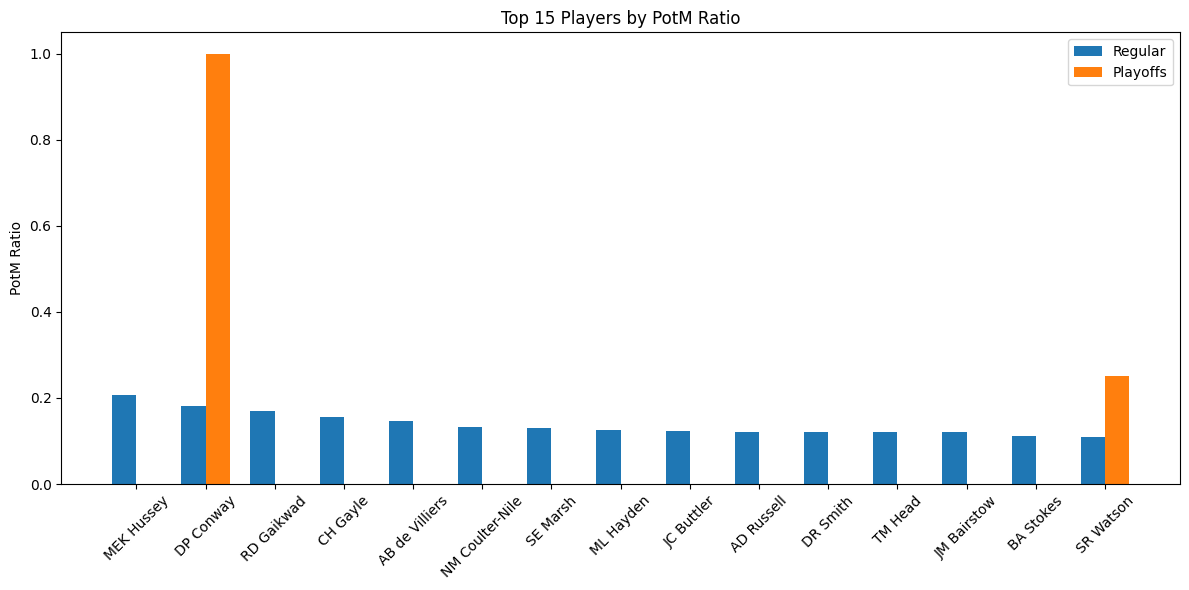

In [184]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(top_players))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, top_players['potm_ratio'], width, label='Regular')
plt.bar(x + width/2, top_players['playoff_ratio'], width, label='Playoffs')

plt.xticks(x, top_players['player'], rotation=45)
plt.ylabel("PotM Ratio")
plt.title("Top 15 Players by PotM Ratio")
plt.legend()

plt.tight_layout()
plt.show()

In [185]:
top_players.head()

,player,matches_played,potm_awards,potm_ratio,playoff_potm,playoff_matches,playoff_ratio
157,MEK Hussey,58,12.0,0.206897,0.0,4.0,0.0
68,DP Conway,22,4.0,0.181818,1.0,1.0,1.0
217,RD Gaikwad,65,11.0,0.169231,0.0,2.0,0.0
49,CH Gayle,141,22.0,0.156028,0.0,2.0,0.0
11,AB de Villiers,170,25.0,0.147059,0.0,2.0,0.0


### Summary & Interpretation

- The chart compares PotM ratio in regular and playoff matches.
- **MEK Hussey** has the highest ratio (~0.207), making him the most consistent match-winner.
- **DP Conway** (0.182) and **RD Gaikwad** (0.169) also show strong performance.
- In playoffs, **DP Conway** and **SR Watson** have higher ratios compared to their regular matches, indicating strong performances under pressure.
- Several players like **RD Gaikwad** and **AB de Villiers** have low or zero playoff PotM awards.

Overall, PotM ratio highlights player efficiency better than total awards.

### Key Insights

- **MEK Hussey** has the highest PotM ratio (**0.207**), meaning he wins Player of the Match more frequently per game than others.
- **DP Conway** also has a high ratio (**0.182**), even though he has played fewer matches.
- Most top players have PotM ratios between **0.12 and 0.20**, which shows that even top players win PotM only in some matches.

- In playoff matches:
  - **DP Conway** and **SR Watson** perform well, with higher ratios compared to their regular matches.
  - Some players have **0 playoff PotM awards**, meaning they perform better in league matches than in pressure situations.

- This shows that players with fewer matches can still have a high impact if they win PotM often.

### Conclusion

- **MEK Hussey** is the most consistent match-winner based on ratio.
- **DP Conway** performs well in both regular and playoff matches.
- Overall, PotM ratio is a better way to measure performance than just total awards.